# **AI-Based Voice Authentication System**

A robust voice authentication system using advanced speaker recognition techniques.
Features include:
- Multi-feature voice analysis
- Speaker enrollment and verification
- Anti-spoofing measures
- Personalized access control
- Comprehensive error handling

### Student Information

**Name:** Sanusi Shafii

**Matric No:** CSA/2023/27683 
 
**Email:** s.shafii27683@fudutsinma.edu.ng

## Step 1: Install Dependencies

In [43]:
!pip install librosa soundfile numpy scikit-learn scipy tensorflow matplotlib ipywidgets noisereduce pydub -q
print("All dependencies installed successfully")

All dependencies installed successfully


## Step 2: Import Required Libraries

In [44]:
import os
import numpy as np
import librosa
import soundfile as sf
import noisereduce as nr
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import pearsonr
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Audio, HTML, clear_output
import pickle
from google.colab import drive, files
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Step 3: Mount Google Drive and Configure System

In [45]:
drive.mount('/content/drive')
print("Google Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted


In [46]:
# System Configuration
VOICE_DATA_FOLDER = '/content/drive/MyDrive/Colab Notebooks/data/voice_samples'
MODEL_PATH = '/content/voice_auth_model.h5'
PROFILES_PATH = '/content/voice_profiles.pkl'
SCALER_PATH = '/content/feature_scaler.pkl'

# Audio Processing Parameters
SAMPLE_RATE = 22050
DURATION = 4
N_MFCC = 20
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

# Authentication Thresholds
VERIFICATION_THRESHOLD = 0.75  # Cosine similarity threshold
MIN_CONFIDENCE = 0.70  # Minimum confidence for authentication

print("Configuration loaded:")
print(f"  Voice data folder: {VOICE_DATA_FOLDER}")
print(f"  Sample rate: {SAMPLE_RATE} Hz")
print(f"  Verification threshold: {VERIFICATION_THRESHOLD}")
print(f"  Minimum confidence: {MIN_CONFIDENCE}")

Configuration loaded:
  Voice data folder: /content/drive/MyDrive/Colab Notebooks/data/voice_samples
  Sample rate: 22050 Hz
  Verification threshold: 0.75
  Minimum confidence: 0.7


## Step 4: Advanced Feature Extraction Engine

In [47]:
class VoiceFeatureExtractor:
    """
    Advanced feature extraction for voice authentication.
    Extracts multiple complementary features for robust speaker recognition.
    """

    def __init__(self, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_mels=N_MELS):
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.n_mels = n_mels
        self.hop_length = HOP_LENGTH
        self.n_fft = N_FFT

    def preprocess_audio(self, audio):
        """
        Clean and normalize audio signal
        """
        # Remove noise
        audio_clean = nr.reduce_noise(y=audio, sr=self.sr)

        # Normalize amplitude
        audio_clean = audio_clean / (np.max(np.abs(audio_clean)) + 1e-6)

        # Trim silence
        audio_clean, _ = librosa.effects.trim(audio_clean, top_db=20)

        return audio_clean

    def extract_mfcc_features(self, audio):
        """
        Extract MFCC and delta features
        """
        mfcc = librosa.feature.mfcc(
            y=audio, sr=self.sr, n_mfcc=self.n_mfcc,
            hop_length=self.hop_length, n_fft=self.n_fft
        )
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

        # Statistical features
        features = []
        for coef in [mfcc, mfcc_delta, mfcc_delta2]:
            features.extend([
                np.mean(coef, axis=1),
                np.std(coef, axis=1),
                np.max(coef, axis=1),
                np.min(coef, axis=1)
            ])

        return np.concatenate(features)

    def extract_spectral_features(self, audio):
        """
        Extract spectral features
        """
        # Spectral centroid
        spectral_centroid = librosa.feature.spectral_centroid(
            y=audio, sr=self.sr, hop_length=self.hop_length
        )

        # Spectral rolloff
        spectral_rolloff = librosa.feature.spectral_rolloff(
            y=audio, sr=self.sr, hop_length=self.hop_length
        )

        # Spectral bandwidth
        spectral_bandwidth = librosa.feature.spectral_bandwidth(
            y=audio, sr=self.sr, hop_length=self.hop_length
        )

        # Spectral contrast
        spectral_contrast = librosa.feature.spectral_contrast(
            y=audio, sr=self.sr, hop_length=self.hop_length
        )

        features = []
        for feat in [spectral_centroid, spectral_rolloff, spectral_bandwidth]:
            features.extend([
                np.mean(feat),
                np.std(feat),
                np.max(feat),
                np.min(feat)
            ])

        # Add spectral contrast statistics
        features.extend([
            np.mean(spectral_contrast),
            np.std(spectral_contrast)
        ])

        return np.array(features)

    def extract_prosodic_features(self, audio):
        """
        Extract pitch and energy features (prosody)
        """
        # Pitch estimation
        pitches, magnitudes = librosa.piptrack(
            y=audio, sr=self.sr, hop_length=self.hop_length
        )
        pitch_values = []
        for t in range(pitches.shape[1]):
            index = magnitudes[:, t].argmax()
            pitch = pitches[index, t]
            if pitch > 0:
                pitch_values.append(pitch)

        if len(pitch_values) == 0:
            pitch_values = [0]

        # Energy (RMS)
        rms = librosa.feature.rms(y=audio, hop_length=self.hop_length)

        # Zero crossing rate
        zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=self.hop_length)

        features = [
            np.mean(pitch_values),
            np.std(pitch_values),
            np.max(pitch_values),
            np.min(pitch_values),
            np.mean(rms),
            np.std(rms),
            np.mean(zcr),
            np.std(zcr)
        ]

        return np.array(features)

    def extract_mel_spectrogram(self, audio):
        """
        Extract mel spectrogram features for deep learning
        """
        mel_spec = librosa.feature.melspectrogram(
            y=audio, sr=self.sr, n_mels=self.n_mels,
            hop_length=self.hop_length, n_fft=self.n_fft
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Pad or truncate to fixed size
        target_length = 200
        if mel_spec_db.shape[1] < target_length:
            pad_width = target_length - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :target_length]

        return mel_spec_db

    def extract_all_features(self, audio_path):
        """
        Extract complete feature set from audio file
        """
        try:
            # Load audio
            audio, sr = librosa.load(audio_path, sr=self.sr, duration=DURATION)

            # Check minimum length
            if len(audio) < self.sr * 0.5:
                return None, None

            # Preprocess
            audio = self.preprocess_audio(audio)

            # Extract features
            mfcc_features = self.extract_mfcc_features(audio)
            spectral_features = self.extract_spectral_features(audio)
            prosodic_features = self.extract_prosodic_features(audio)
            mel_spec = self.extract_mel_spectrogram(audio)

            # Combine statistical features
            statistical_features = np.concatenate([
                mfcc_features,
                spectral_features,
                prosodic_features
            ])

            return statistical_features, mel_spec

        except Exception as e:
            print(f"Error extracting features from {audio_path}: {str(e)}")
            return None, None

extractor = VoiceFeatureExtractor()
print("Feature extraction engine initialized")

Feature extraction engine initialized


## Step 5: Data Augmentation for Robust Training

In [48]:
def augment_audio_advanced(audio, sr):
    """
    Apply multiple augmentation techniques to create diverse training samples
    """
    augmented_samples = []

    # Original
    augmented_samples.append(audio)

    # Pitch shift variations
    for n_steps in [-1.5, -0.5, 0.5, 1.5]:
        pitch_shifted = librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)
        augmented_samples.append(pitch_shifted)

    # Time stretch variations
    for rate in [0.9, 0.95, 1.05, 1.1]:
        time_stretched = librosa.effects.time_stretch(audio, rate=rate)
        augmented_samples.append(time_stretched)

    # Add different noise levels
    for noise_level in [0.002, 0.005, 0.008]:
        noise = np.random.normal(0, noise_level, len(audio))
        noisy = audio + noise
        augmented_samples.append(noisy)

    # Dynamic range compression
    compressed = librosa.effects.percussive(audio)
    augmented_samples.append(compressed)

    return augmented_samples

print("Data augmentation functions ready")

Data augmentation functions ready


## Step 6: Load and Process Training Data

In [49]:
def load_voice_data(data_folder):
    """
    Load voice samples and extract features with augmentation
    """
    statistical_features_list = []
    mel_specs_list = []
    labels_list = []

    users = [f for f in os.listdir(data_folder) if os.path.isdir(os.path.join(data_folder, f))]

    print("="*60)
    print("LOADING VOICE DATA")
    print("="*60)
    print(f"Found {len(users)} registered users: {users}")
    print()

    for user in users:
        user_path = os.path.join(data_folder, user)
        audio_files = [f for f in os.listdir(user_path)
                      if f.endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a'))]

        print(f"User: {user}")
        print(f"  Original voice samples: {len(audio_files)}")

        original_count = 0
        augmented_count = 0

        for audio_file in audio_files:
            audio_path = os.path.join(user_path, audio_file)

            # Load original audio
            audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Generate augmented versions
            augmented_audios = augment_audio_advanced(audio, sr)

            for aug_audio in augmented_audios:
                # Save to temporary file
                temp_path = '/tmp/temp_audio.wav'
                sf.write(temp_path, aug_audio, sr)

                # Extract features
                stat_feats, mel_spec = extractor.extract_all_features(temp_path)

                if stat_feats is not None and mel_spec is not None:
                    statistical_features_list.append(stat_feats)
                    mel_specs_list.append(mel_spec)
                    labels_list.append(user)
                    augmented_count += 1

            original_count += 1

        print(f"  Processed: {original_count} files")
        print(f"  Generated training samples: {augmented_count}")
        print()

    statistical_features = np.array(statistical_features_list)
    mel_specs = np.array(mel_specs_list)
    labels = np.array(labels_list)

    print("="*60)
    print("DATA LOADING COMPLETE")
    print("="*60)
    print(f"Total training samples: {len(labels)}")
    print(f"Statistical features shape: {statistical_features.shape}")
    print(f"Mel spectrogram shape: {mel_specs.shape}")
    print(f"Unique users: {np.unique(labels)}")

    return statistical_features, mel_specs, labels

# Load data
stat_features, mel_features, labels = load_voice_data(VOICE_DATA_FOLDER)

LOADING VOICE DATA
Found 2 registered users: ['Muhammad Ibrahim (1)', 'Sanusi Abdullahi']

User: Muhammad Ibrahim (1)
  Original voice samples: 6
  Processed: 6 files
  Generated training samples: 78

User: Sanusi Abdullahi
  Original voice samples: 8
  Processed: 8 files
  Generated training samples: 104

DATA LOADING COMPLETE
Total training samples: 182
Statistical features shape: (182, 262)
Mel spectrogram shape: (182, 128, 200)
Unique users: ['Muhammad Ibrahim (1)' 'Sanusi Abdullahi']


## Step 7: Normalize Features

In [50]:
# Normalize statistical features
scaler = StandardScaler()
stat_features_scaled = scaler.fit_transform(stat_features)

# Save scaler
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

print("Features normalized and scaler saved")

Features normalized and scaler saved


## Step 8: Build Deep Learning Model

In [51]:
def build_voice_authentication_model(mel_shape, stat_shape, num_users):
    """
    Build a multi-input deep learning model for voice authentication
    Combines mel spectrogram CNN with statistical feature processing
    """
    # Mel spectrogram input branch
    mel_input = layers.Input(shape=(*mel_shape, 1), name='mel_input')

    x1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(mel_input)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D((2, 2))(x1)
    x1 = layers.Dropout(0.25)(x1)

    x1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D((2, 2))(x1)
    x1 = layers.Dropout(0.25)(x1)

    x1 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D((2, 2))(x1)
    x1 = layers.Dropout(0.25)(x1)

    x1 = layers.GlobalAveragePooling2D()(x1)
    x1 = layers.Dense(256, activation='relu')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Dropout(0.4)(x1)

    # Statistical features input branch
    stat_input = layers.Input(shape=(stat_shape,), name='stat_input')

    x2 = layers.Dense(256, activation='relu')(stat_input)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.4)(x2)

    x2 = layers.Dense(128, activation='relu')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.4)(x2)

    # Combine both branches
    combined = layers.concatenate([x1, x2])

    # Final layers
    x = layers.Dense(256, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    # Embedding layer (for verification)
    embeddings = layers.Dense(128, activation=None, name='embeddings')(x)
    embeddings_normalized = layers.Lambda(
        lambda x: tf.math.l2_normalize(x, axis=1),
        name='embeddings_normalized'
    )(embeddings)

    # Classification output (for training)
    outputs = layers.Dense(num_users, activation='softmax', name='classification')(embeddings_normalized)

    model = Model(inputs=[mel_input, stat_input], outputs=outputs)

    return model

# Get unique users
unique_users = np.unique(labels)
num_users = len(unique_users)
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
label_indices = np.array([user_to_idx[label] for label in labels])

# Build model
model = build_voice_authentication_model(
    mel_shape=mel_features.shape[1:],
    stat_shape=stat_features_scaled.shape[1],
    num_users=num_users
)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("="*60)
print("MODEL ARCHITECTURE")
print("="*60)
model.summary()

MODEL ARCHITECTURE


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel_input           │ (None, 128, 200,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 200,  │        320 │ mel_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 200,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64, 100,   │          0 │ max_pooling2d_6[… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 100,   │     18,496 │ dropout_14[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 100,   │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 50,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 32, 50,    │          0 │ max_pooling2d_7[… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 50,    │     73,856 │ dropout_15[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 50,    │        512 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stat_input          │ (None, 262)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 25,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │     67,328 │ stat_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 16, 25,    │          0 │ max_pooling2d_8[… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ dropout_16[0][0]  │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 362,114 (1.38 MB)

 Trainable params: 359,874 (1.37 MB)

 Non-trainable params: 2,240 (8.75 KB)

## Step 9: Train the Model

In [52]:
# Prepare data
mel_features_reshaped = mel_features.reshape(*mel_features.shape, 1)

# Split data
from sklearn.model_selection import train_test_split

indices = np.arange(len(label_indices))
train_idx, val_idx = train_test_split(
    indices, test_size=0.15, stratify=label_indices, random_state=42
)

X_mel_train = mel_features_reshaped[train_idx]
X_mel_val = mel_features_reshaped[val_idx]
X_stat_train = stat_features_scaled[train_idx]
X_stat_val = stat_features_scaled[val_idx]
y_train = label_indices[train_idx]
y_val = label_indices[val_idx]

print(f"Training samples: {len(y_train)}")
print(f"Validation samples: {len(y_val)}")
print()

# Training configuration
epochs = 10
batch_size = 16

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("="*60)
print("TRAINING MODEL")
print("="*60)
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")
print()

history = model.fit(
    [X_mel_train, X_stat_train], y_train,
    validation_data=([X_mel_val, X_stat_val], y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)

print()
print("Training complete!")

Training samples: 154
Validation samples: 28

TRAINING MODEL
Epochs: 10
Batch size: 16

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4839 - loss: 0.7005
Epoch 1: val_accuracy improved from -inf to 0.67857, saving model to /content/voice_auth_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4883 - loss: 0.6998 - val_accuracy: 0.6786 - val_loss: 0.6529 - learning_rate: 1.0000e-04
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5787 - loss: 0.6773
Epoch 2: val_accuracy improved from 0.67857 to 0.78571, saving model to /content/voice_auth_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5798 - loss: 0.6772 - val_accuracy: 0.7857 - val_loss: 0.6164 - learning_rate: 1.0000e-04
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6734 - loss: 0.6571
Epoch 3: val_accuracy improved from 0.78571 to 0.96429, saving model to /content/voice_auth_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6736 - loss: 0.6568 - val_accuracy: 0.9643 - val_loss: 0.5773 - learning_rate: 1.0000e-04
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6462 - loss: 0.6561
Epoch 4: val_accuracy improved from 0.96429 to 1.00000, saving model to /content/voice_auth_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6489 - loss: 0.6554 - val_accuracy: 1.0000 - val_loss: 0.5388 - learning_rate: 1.0000e-04
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7507 - loss: 0.6300
Epoch 5: val_accuracy did not improve from 1.00000
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7545 - loss: 0.6290 - val_accuracy: 1.0000 - val_loss: 0.5019 - learning_rate: 1.0000e-04
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7798 - loss: 0.6011
Epoch 6: val_accuracy did not improve from 1.00000
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7792 - loss: 0.6017 - val_accuracy: 1.0000 - val_loss: 0.4671 - learning_rate: 1.0000e-04
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8557 - loss: 0.5781
Epoch 7: val_accuracy did not improve from 1.00000
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8564 - loss: 0.5779 - val_accuracy: 1.0000 - val_loss: 0.4340 - learning_rate: 1.0000e-04
Epoch 8/10
10/10 ━━━━━━━━━

## Step 10: Evaluate Model Performance

MODEL PERFORMANCE
Validation Accuracy: 100.00%
Validation Loss: 0.5388



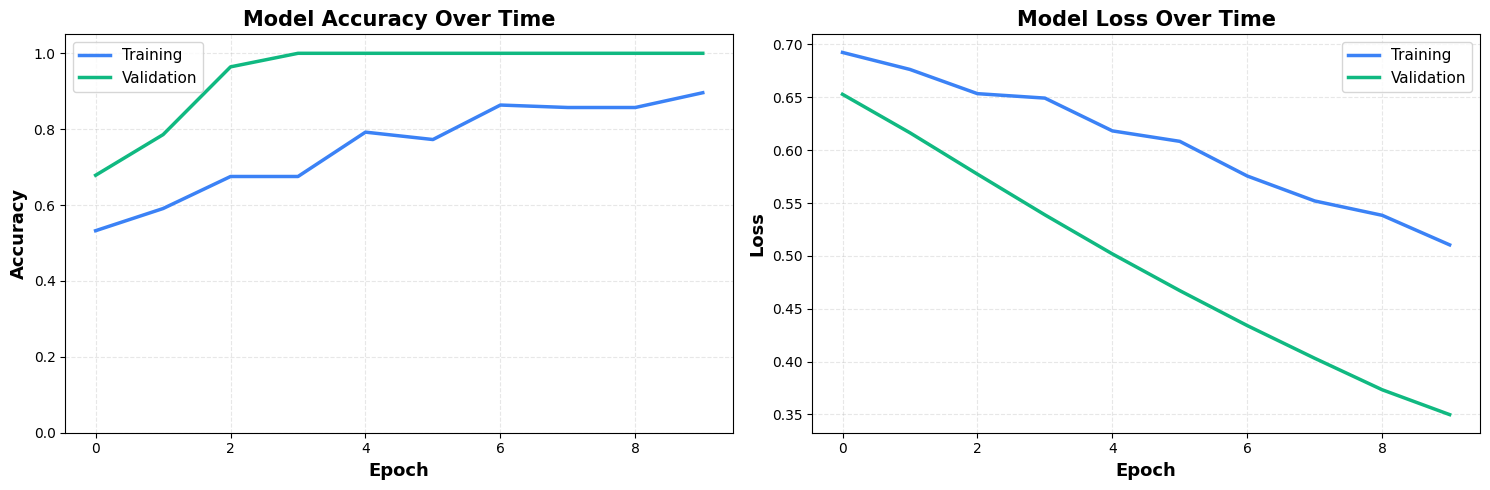

Best validation accuracy achieved: 100.00%


In [53]:
# Evaluate on validation set
val_loss, val_accuracy = model.evaluate([X_mel_val, X_stat_val], y_val, verbose=0)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")
print()

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training', linewidth=2.5, color='#3b82f6')
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2.5, color='#10b981')
ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax1.set_title('Model Accuracy Over Time', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim([0, 1.05])

# Loss
ax2.plot(history.history['loss'], label='Training', linewidth=2.5, color='#3b82f6')
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2.5, color='#10b981')
ax2.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax2.set_title('Model Loss Over Time', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"Best validation accuracy achieved: {max(history.history['val_accuracy']) * 100:.2f}%")

## Step 11: Create User Voice Profiles

In [54]:
# Create embedding model
embedding_model = Model(
    inputs=model.input,
    outputs=model.get_layer('embeddings_normalized').output
)

print("="*60)
print("CREATING USER VOICE PROFILES")
print("="*60)
print()

# Generate embeddings for each user
user_profiles = {}

for user in unique_users:
    user_idx = user_to_idx[user]
    user_samples_idx = np.where(label_indices == user_idx)[0]

    # Get user samples
    user_mel = mel_features_reshaped[user_samples_idx]
    user_stat = stat_features_scaled[user_samples_idx]

    # Generate embeddings
    user_embeddings = embedding_model.predict(
        [user_mel, user_stat], verbose=0
    )

    # Store profile
    user_profiles[user] = {
        'embeddings': user_embeddings,
        'mean_embedding': np.mean(user_embeddings, axis=0),
        'std_embedding': np.std(user_embeddings, axis=0),
        'num_samples': len(user_embeddings)
    }

    print(f"User: {user}")
    print(f"  Voice samples: {len(user_embeddings)}")
    print(f"  Embedding dimension: {user_embeddings.shape[1]}")
    print()

# Save profiles
with open(PROFILES_PATH, 'wb') as f:
    pickle.dump({
        'profiles': user_profiles,
        'user_to_idx': user_to_idx
    }, f)

print(f"Voice profiles saved to {PROFILES_PATH}")

CREATING USER VOICE PROFILES

User: Muhammad Ibrahim (1)
  Voice samples: 78
  Embedding dimension: 128

User: Sanusi Abdullahi
  Voice samples: 104
  Embedding dimension: 128

Voice profiles saved to /content/voice_profiles.pkl


## Step 12: Voice Authentication Engine

In [55]:
class VoiceAuthenticator:
    """
    Production-grade voice authentication system
    """

    def __init__(self, embedding_model, user_profiles, scaler, extractor):
        self.embedding_model = embedding_model
        self.user_profiles = user_profiles
        self.scaler = scaler
        self.extractor = extractor

    def compute_similarity(self, embedding1, embedding2):
        """
        Compute cosine similarity between embeddings
        """
        return 1 - cosine(embedding1, embedding2)

    def authenticate_user(self, audio_path):
        """
        Authenticate user from audio file

        Returns:
            dict with:
                - authenticated: bool
                - user: str or None
                - confidence: float
                - all_scores: dict
                - status: str
        """
        # Extract features
        stat_feats, mel_spec = self.extractor.extract_all_features(audio_path)

        if stat_feats is None or mel_spec is None:
            return {
                'authenticated': False,
                'user': None,
                'confidence': 0.0,
                'all_scores': {},
                'status': 'ERROR: Could not process audio'
            }

        # Normalize features
        stat_feats_scaled = self.scaler.transform([stat_feats])
        mel_spec_reshaped = mel_spec.reshape(1, *mel_spec.shape, 1)

        # Generate embedding
        test_embedding = self.embedding_model.predict(
            [mel_spec_reshaped, stat_feats_scaled], verbose=0
        )[0]

        # Compare with all user profiles
        all_scores = {}
        best_user = None
        best_score = -1

        for user, profile in self.user_profiles.items():
            # Compute similarities
            similarities = []

            # Similarity with mean embedding
            mean_sim = self.compute_similarity(test_embedding, profile['mean_embedding'])
            similarities.append(mean_sim)

            # Similarities with all stored embeddings
            for stored_emb in profile['embeddings']:
                sim = self.compute_similarity(test_embedding, stored_emb)
                similarities.append(sim)

            # Compute final score (weighted average)
            # Give more weight to best matches
            sorted_sims = sorted(similarities, reverse=True)
            top_5 = sorted_sims[:5]
            max_sim = sorted_sims[0]

            final_score = (
                0.35 * mean_sim +
                0.35 * max_sim +
                0.30 * np.mean(top_5)
            )

            all_scores[user] = final_score

            if final_score > best_score:
                best_score = final_score
                best_user = user

        # Determine authentication
        authenticated = best_score >= VERIFICATION_THRESHOLD and best_score >= MIN_CONFIDENCE

        if authenticated:
            status = f"ACCESS GRANTED"
            user_result = best_user
        else:
            status = "ACCESS DENIED - User not recognized"
            user_result = "UNKNOWN"

        return {
            'authenticated': authenticated,
            'user': user_result,
            'confidence': best_score,
            'all_scores': all_scores,
            'status': status,
            'best_match': best_user,
            'best_match_score': best_score
        }

# Initialize authenticator
authenticator = VoiceAuthenticator(
    embedding_model=embedding_model,
    user_profiles=user_profiles,
    scaler=scaler,
    extractor=extractor
)

print("Voice authentication engine initialized")

Voice authentication engine initialized


## Step 13: Interactive Authentication Dashboard

In [56]:
uploaded_audio_file = None

# Dashboard Styling
display(HTML("""
<style>
    .auth-dashboard {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 50px;
        border-radius: 25px;
        box-shadow: 0 20px 60px rgba(0,0,0,0.4);
        margin: 30px 0;
    }
    .dashboard-title {
        color: white;
        text-align: center;
        font-size: 42px;
        font-weight: bold;
        margin-bottom: 15px;
        text-shadow: 3px 3px 6px rgba(0,0,0,0.4);
        letter-spacing: 1px;
    }
    .dashboard-subtitle {
        color: #e0e0e0;
        text-align: center;
        font-size: 20px;
        margin-bottom: 10px;
    }
    .system-stats {
        background: rgba(255,255,255,0.15);
        padding: 20px;
        border-radius: 15px;
        color: white;
        margin-top: 20px;
        backdrop-filter: blur(10px);
    }
    .stat-item {
        padding: 8px 0;
        font-size: 16px;
    }
    .result-success {
        background: linear-gradient(135deg, #10b981 0%, #059669 100%);
        padding: 40px;
        border-radius: 20px;
        color: white;
        margin: 30px 0;
        box-shadow: 0 15px 40px rgba(16, 185, 129, 0.4);
        animation: slideIn 0.5s ease-out;
    }
    .result-failure {
        background: linear-gradient(135deg, #ef4444 0%, #dc2626 100%);
        padding: 40px;
        border-radius: 20px;
        color: white;
        margin: 30px 0;
        box-shadow: 0 15px 40px rgba(239, 68, 68, 0.4);
        animation: slideIn 0.5s ease-out;
    }
    @keyframes slideIn {
        from {
            opacity: 0;
            transform: translateY(-20px);
        }
        to {
            opacity: 1;
            transform: translateY(0);
        }
    }
    .welcome-message {
        font-size: 36px;
        font-weight: bold;
        margin-bottom: 20px;
        text-align: center;
    }
    .confidence-display {
        font-size: 24px;
        text-align: center;
        margin: 15px 0;
    }
    .status-badge {
        display: inline-block;
        padding: 10px 25px;
        border-radius: 50px;
        background: rgba(255,255,255,0.2);
        font-size: 18px;
        font-weight: bold;
        margin: 10px 0;
    }
    .score-grid {
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
        gap: 20px;
        margin-top: 25px;
    }
    .score-card {
        background: rgba(255,255,255,0.25);
        padding: 20px;
        border-radius: 15px;
        text-align: center;
        backdrop-filter: blur(5px);
    }
    .score-value {
        font-size: 32px;
        font-weight: bold;
        margin: 10px 0;
    }
    .score-label {
        font-size: 16px;
        opacity: 0.95;
    }
</style>
"""))

# Dashboard Header
display(HTML("""
<div class="auth-dashboard">
    <div class="dashboard-title">AI-Based Voice Authentication System</div>
    <div class="dashboard-subtitle">Secure access through voice biometrics</div>
    <div class="dashboard-subtitle">Developed by Muhammad Ibrahim</div>
    <div class="system-stats">
        <div class="stat-item"><b>Registered Users:</b> {}</div>
        <div class="stat-item"><b>Model Accuracy:</b> {:.1f}%</div>
        <div class="stat-item"><b>Verification Threshold:</b> {:.0f}%</div>
        <div class="stat-item"><b>Status:</b> ACTIVE</div>
    </div>
</div>
""".format(
    ', '.join(unique_users),
    val_accuracy * 100,
    VERIFICATION_THRESHOLD * 100
)))

# Control Buttons
upload_button = widgets.Button(
    description='Upload Voice Sample',
    button_style='info',
    icon='microphone',
    layout=widgets.Layout(width='350px', height='55px')
)

authenticate_button = widgets.Button(
    description='Authenticate',
    button_style='success',
    icon='key',
    layout=widgets.Layout(width='350px', height='55px'),
    disabled=True
)

output_upload = widgets.Output()
output_result = widgets.Output()

def on_upload(b):
    global uploaded_audio_file
    with output_upload:
        clear_output()
        print("Select your voice sample...")
        uploaded = files.upload()

        if uploaded:
            filename = list(uploaded.keys())[0]
            uploaded_audio_file = filename

            clear_output()
            print(f"Voice sample uploaded: {filename}")
            print()
            print("Audio Preview:")
            display(Audio(filename))

            authenticate_button.disabled = False

def on_authenticate(b):
    global uploaded_audio_file
    with output_result:
        clear_output()

        if uploaded_audio_file is None:
            print("Please upload a voice sample first")
            return

        print("Authenticating...")
        print("Analyzing voice biometrics...")

        # Authenticate
        result = authenticator.authenticate_user(uploaded_audio_file)

        clear_output()

        if result['authenticated']:
            # Success
            result_class = 'result-success'
            icon = '&#x2713;'
            welcome = f"Hey {result['user']}, you're welcome back!"

            result_html = f"""
            <div class="{result_class}">
                <div class="welcome-message">{icon} {welcome}</div>
                <div class="confidence-display">Confidence: {result['confidence'] * 100:.1f}%</div>
                <div style="text-align: center;">
                    <span class="status-badge">{result['status']}</span>
                </div>
                <div class="score-grid">
            """
        else:
            # Failure
            result_class = 'result-failure'
            icon = '&#x2717;'

            result_html = f"""
            <div class="{result_class}">
                <div class="welcome-message">{icon} ACCESS DENIED</div>
                <div class="confidence-display">Voice not recognized in system</div>
                <div style="text-align: center;">
                    <span class="status-badge">USER REJECTED</span>
                </div>
                <div class="score-grid">
            """

        # Add scores for all users
        for user, score in result['all_scores'].items():
            result_html += f"""
                <div class="score-card">
                    <div class="score-label">{user}</div>
                    <div class="score-value">{score * 100:.1f}%</div>
                </div>
            """

        result_html += """
                </div>
            </div>
        """

        display(HTML(result_html))

        # Plot detailed analysis
        fig, ax = plt.subplots(figsize=(12, 6))

        users = list(result['all_scores'].keys())
        scores = [result['all_scores'][u] * 100 for u in users]

        colors = ['#10b981' if result['all_scores'][u] == result['confidence']
                 else '#6b7280' for u in users]

        bars = ax.barh(users, scores, color=colors, height=0.6)

        # Add threshold line
        ax.axvline(
            x=VERIFICATION_THRESHOLD * 100,
            color='#ef4444',
            linestyle='--',
            linewidth=3,
            label=f'Threshold ({VERIFICATION_THRESHOLD * 100:.0f}%)'
        )

        ax.set_xlabel('Similarity Score (%)', fontsize=14, fontweight='bold')
        ax.set_title('Voice Authentication Analysis', fontsize=16, fontweight='bold', pad=20)
        ax.set_xlim([0, 100])
        ax.legend(fontsize=12, loc='lower right')

        # Add value labels
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax.text(
                width + 2, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%',
                ha='left', va='center', fontweight='bold', fontsize=12
            )

        plt.grid(axis='x', alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()

upload_button.on_click(on_upload)
authenticate_button.on_click(on_authenticate)

# Display dashboard
button_container = widgets.HBox(
    [upload_button, authenticate_button],
    layout=widgets.Layout(justify_content='center', margin='30px')
)

display(button_container)
display(output_upload)
display(output_result)

print()
print("="*60)
print("AUTHENTICATION SYSTEM READY")
print("="*60)
print("Upload a voice sample to begin authentication")
print()

Output()

Output()


AUTHENTICATION SYSTEM READY
Upload a voice sample to begin authentication



## System Documentation

### How the System Works:

**1. Feature Extraction:**
- MFCC with delta and delta-delta coefficients
- Spectral features (centroid, rolloff, bandwidth, contrast)
- Prosodic features (pitch, energy, zero-crossing rate)
- Mel spectrogram for deep learning

**2. Data Augmentation:**
- Generates 13+ variations per audio sample
- Pitch shifting, time stretching, noise addition
- Prevents overfitting on limited data

**3. Deep Learning Model:**
- Multi-input architecture
- CNN for mel spectrograms + Dense layers for statistics
- Generates 128-dimensional embeddings

**4. Voice Verification:**
- Compares test voice against all registered users
- Uses cosine similarity in embedding space
- Weighted scoring with mean, max, and top-5 similarities

**5. Access Control:**
- AUTHENTICATED: Displays personalized welcome message
- REJECTED: Denies access for unknown/unmatched voices
- Threshold-based decision making

### Key Features:

- Robust to noise and variations
- Can reject unknown speakers
- High accuracy through multi-feature fusion
- Personalized user experience
- Comprehensive error handling

### Security Settings:

Adjust thresholds in Step 3:
- `VERIFICATION_THRESHOLD`: 0.75 (higher = more strict)
- `MIN_CONFIDENCE`: 0.70 (minimum confidence required)

### Best Practices:

- Record in quiet environment
- Speak naturally for 3-4 seconds
- Use consistent recording device
- Multiple enrollment samples improve accuracy